In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
#INTRODUCTION
#This project analyzes global indicators using World Bank datasets. The objective is to explore relationships 
#between GDP growth, inflation, unemployment, trade openness, CO2 emissions, education, population growth, and foreign direct
#investment across multiple countries and time periods.

In [3]:
#Loading World Bank's GDP Growth data
GDP_df = pd.read_csv("WB_GDP_Growth.csv")
print(GDP_df)

           STRUCTURE                STRUCTURE_ID ACTION FREQ REF_AREA  \
0      datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      UZB   
1      datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VUT   
2      datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VEN   
3      datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VNM   
4      datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PSE   
...              ...                         ...    ...  ...      ...   
14128  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      BOL   
14129  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      BWA   
14130  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      BRA   
14131  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      BFA   
14132  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      BDI   

                      INDICATOR SEX AGE URBANISATION UNIT_MEASURE  ...  \
0      WB_WDI_NY_GDP_MKTP_KD_ZG  _T  _T          

In [4]:
GDP_df = GDP_df[[
    'REF_AREA',
    'REF_AREA_LABEL',
    'TIME_PERIOD',
    'OBS_VALUE'
]]
print(GDP_df)

      REF_AREA      REF_AREA_LABEL  TIME_PERIOD  OBS_VALUE
0          UZB          Uzbekistan         1999   4.300000
1          VUT             Vanuatu         1999   0.337293
2          VEN       Venezuela, RB         1999  -5.970458
3          VNM             Vietnam         1999   4.773587
4          PSE  West Bank and Gaza         1999   8.280591
...        ...                 ...          ...        ...
14128      BOL             Bolivia         1961   2.089296
14129      BWA            Botswana         1961   6.343284
14130      BRA              Brazil         1961   8.600000
14131      BFA        Burkina Faso         1961   4.043928
14132      BDI             Burundi         1961 -13.746135

[14133 rows x 4 columns]


In [5]:
GDP_df.columns = [
    'Country_Code',
    'Country',
    'Year',
    'GDP_Growth'
]
print(GDP_df)

      Country_Code             Country  Year  GDP_Growth
0              UZB          Uzbekistan  1999    4.300000
1              VUT             Vanuatu  1999    0.337293
2              VEN       Venezuela, RB  1999   -5.970458
3              VNM             Vietnam  1999    4.773587
4              PSE  West Bank and Gaza  1999    8.280591
...            ...                 ...   ...         ...
14128          BOL             Bolivia  1961    2.089296
14129          BWA            Botswana  1961    6.343284
14130          BRA              Brazil  1961    8.600000
14131          BFA        Burkina Faso  1961    4.043928
14132          BDI             Burundi  1961  -13.746135

[14133 rows x 4 columns]


In [6]:
#Loading World Bank's Inflation data
Inflation_df = pd.read_csv("WB_Inflation.csv")
print(Inflation_df)

          STRUCTURE                STRUCTURE_ID ACTION FREQ REF_AREA  \
0     datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VUT   
1     datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VNM   
2     datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PSE   
3     datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      YEM   
4     datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      ZMB   
...             ...                         ...    ...  ...      ...   
9061  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PAN   
9062  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PRY   
9063  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PER   
9064  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PHL   
9065  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PRT   

                  INDICATOR SEX AGE URBANISATION UNIT_MEASURE  ...  \
0     WB_WDI_FP_CPI_TOTL_ZG  _T  _T           _T         PC_A  ..

In [7]:
Inflation_df = Inflation_df[[
    'REF_AREA',
    'REF_AREA_LABEL',
    'TIME_PERIOD',
    'OBS_VALUE'
]]
print(Inflation_df)

     REF_AREA      REF_AREA_LABEL  TIME_PERIOD  OBS_VALUE
0         VUT             Vanuatu         1999   1.998975
1         VNM             Vietnam         1999   4.117102
2         PSE  West Bank and Gaza         1999   5.544392
3         YEM         Yemen, Rep.         1999   8.660219
4         ZMB              Zambia         1999  26.787697
...       ...                 ...          ...        ...
9061      PAN              Panama         1960   0.051177
9062      PRY            Paraguay         1960   8.181818
9063      PER                Peru         1960   8.664459
9064      PHL         Philippines         1960   4.154822
9065      PRT            Portugal         1960   3.046593

[9066 rows x 4 columns]


In [8]:
Inflation_df.columns = [
    'Country_Code',
    'Country',
    'Year',
    'Inflation'
]
print(Inflation_df)

     Country_Code             Country  Year  Inflation
0             VUT             Vanuatu  1999   1.998975
1             VNM             Vietnam  1999   4.117102
2             PSE  West Bank and Gaza  1999   5.544392
3             YEM         Yemen, Rep.  1999   8.660219
4             ZMB              Zambia  1999  26.787697
...           ...                 ...   ...        ...
9061          PAN              Panama  1960   0.051177
9062          PRY            Paraguay  1960   8.181818
9063          PER                Peru  1960   8.664459
9064          PHL         Philippines  1960   4.154822
9065          PRT            Portugal  1960   3.046593

[9066 rows x 4 columns]


In [9]:
#Loading World Bank's Unemployment data
Unemployment_df = pd.read_csv("WB_Unemployment.csv")
print(Unemployment_df)

          STRUCTURE                STRUCTURE_ID ACTION FREQ REF_AREA  \
0     datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      URY   
1     datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VNM   
2     datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      YEM   
3     datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      ZWE   
4     datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      CEB   
...             ...                         ...    ...  ...      ...   
5957  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PRI   
5958  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      ESP   
5959  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      GBR   
5960  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      USA   
5961  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PSE   

                     INDICATOR SEX AGE URBANISATION UNIT_MEASURE  ...  \
0     WB_WDI_SL_UEM_TOTL_NE_ZS  _T  _T           _T        PT_

In [10]:
Unemployment_df = Unemployment_df[[
     'REF_AREA',
    'REF_AREA_LABEL',
    'TIME_PERIOD',
    'OBS_VALUE']]
print(Unemployment_df)

     REF_AREA                  REF_AREA_LABEL  TIME_PERIOD  OBS_VALUE
0         URY                         Uruguay         1999   10.46600
1         VNM                         Vietnam         1999    2.32900
2         YEM                     Yemen, Rep.         1999   11.46400
3         ZWE                        Zimbabwe         1999    6.00000
4         CEB  Central Europe and the Baltics         2000   12.14937
...       ...                             ...          ...        ...
5957      PRI                     Puerto Rico         2025    5.61100
5958      ESP                           Spain         2025   10.50400
5959      GBR                  United Kingdom         2025    4.89600
5960      USA                   United States         2025    4.28200
5961      PSE              West Bank and Gaza         2025   28.71000

[5962 rows x 4 columns]


In [11]:
Unemployment_df.columns = [
    'Country_Code',
    'Country',
    'Year',
    'Unemployment %'
]
print(Unemployment_df.dtypes)


Country_Code       object
Country            object
Year                int64
Unemployment %    float64
dtype: object


In [12]:
print(Unemployment_df)

     Country_Code                         Country  Year  Unemployment %
0             URY                         Uruguay  1999        10.46600
1             VNM                         Vietnam  1999         2.32900
2             YEM                     Yemen, Rep.  1999        11.46400
3             ZWE                        Zimbabwe  1999         6.00000
4             CEB  Central Europe and the Baltics  2000        12.14937
...           ...                             ...   ...             ...
5957          PRI                     Puerto Rico  2025         5.61100
5958          ESP                           Spain  2025        10.50400
5959          GBR                  United Kingdom  2025         4.89600
5960          USA                   United States  2025         4.28200
5961          PSE              West Bank and Gaza  2025        28.71000

[5962 rows x 4 columns]


In [13]:
#Loading World Bank's Trade data
Trade_df = pd.read_csv("WB_Trade.csv")
print(Trade_df)

           STRUCTURE                STRUCTURE_ID ACTION FREQ REF_AREA  \
0      datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      URY   
1      datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      UZB   
2      datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VUT   
3      datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VEN   
4      datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VNM   
...              ...                         ...    ...  ...      ...   
10924  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      NER   
10925  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      NGA   
10926  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PAK   
10927  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PAN   
10928  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PER   

                   INDICATOR SEX AGE URBANISATION UNIT_MEASURE  ...  \
0      WB_WDI_NE_TRD_GNFS_ZS  _T  _T           _T   

In [18]:
Trade_df = Trade_df[[
    'REF_AREA',
    'REF_AREA_LABEL',
    'TIME_PERIOD',
    'OBS_VALUE'   
]]
print(Trade_df)

Trade_df.columns = [
    'Country_Code',
    'Country',
    'Year',
    'Trade %'
]
print(Trade_df)

      REF_AREA REF_AREA_LABEL  TIME_PERIOD   OBS_VALUE
0          URY        Uruguay         1999   33.386449
1          UZB     Uzbekistan         1999   36.618859
2          VUT        Vanuatu         1999   91.232330
3          VEN  Venezuela, RB         1999   42.070230
4          VNM        Vietnam         1999  102.787407
...        ...            ...          ...         ...
10924      NER          Niger         1960   14.505754
10925      NGA        Nigeria         1960   26.166513
10926      PAK       Pakistan         1960   20.393189
10927      PAN         Panama         1960  100.168148
10928      PER           Peru         1960   40.481308

[10929 rows x 4 columns]
      Country_Code        Country  Year     Trade %
0              URY        Uruguay  1999   33.386449
1              UZB     Uzbekistan  1999   36.618859
2              VUT        Vanuatu  1999   91.232330
3              VEN  Venezuela, RB  1999   42.070230
4              VNM        Vietnam  1999  102.787407
..

In [19]:
#Loading World Bank's Population Growth data
Population_df = pd.read_csv("WB_Population_Growth.csv")
Population_df = Population_df[[
    'REF_AREA',
    'REF_AREA_LABEL',
    'TIME_PERIOD',
    'OBS_VALUE'   
]]
print(Population_df)


      REF_AREA          REF_AREA_LABEL  TIME_PERIOD  OBS_VALUE
0          UZB              Uzbekistan         1999   1.403325
1          VUT                 Vanuatu         1999   2.072996
2          VEN           Venezuela, RB         1999   1.952133
3          VNM                 Vietnam         1999   1.303285
4          VIR   Virgin Islands (U.S.)         1999   0.057107
...        ...                     ...          ...        ...
16923      BRA                  Brazil         1961   3.017124
16924      VGB  British Virgin Islands         1961   1.051061
16925      BRN       Brunei Darussalam         1961   4.612017
16926      BGR                Bulgaria         1961   0.958156
16927      BFA            Burkina Faso         1961   1.446044

[16928 rows x 4 columns]


In [20]:
Population_df.columns = [
    'Country_Code',
    'Country',
    'Year',
    'Population %'
]
print(Population_df)

      Country_Code                 Country  Year  Population %
0              UZB              Uzbekistan  1999      1.403325
1              VUT                 Vanuatu  1999      2.072996
2              VEN           Venezuela, RB  1999      1.952133
3              VNM                 Vietnam  1999      1.303285
4              VIR   Virgin Islands (U.S.)  1999      0.057107
...            ...                     ...   ...           ...
16923          BRA                  Brazil  1961      3.017124
16924          VGB  British Virgin Islands  1961      1.051061
16925          BRN       Brunei Darussalam  1961      4.612017
16926          BGR                Bulgaria  1961      0.958156
16927          BFA            Burkina Faso  1961      1.446044

[16928 rows x 4 columns]


In [21]:
#Loading World Bank's CO2 Emission data
CO2_df = pd.read_csv("WB_CO2_Emissions.csv")
CO2_df = CO2_df[[
    'REF_AREA',
    'REF_AREA_LABEL',
    'TIME_PERIOD',
    'OBS_VALUE'   
]]
print(CO2_df)

     REF_AREA REF_AREA_LABEL  TIME_PERIOD  OBS_VALUE
0         AFG    Afghanistan         1990   0.169926
1         AGO         Angola         1990   0.564596
2         ALB        Albania         1990   1.844035
3         AND        Andorra         1990   7.732456
4         ARB     Arab World         1990   2.833859
...       ...            ...          ...        ...
7341      WSM          Samoa         2020   0.974314
7342      YEM    Yemen, Rep.         2020   0.275637
7343      ZAF   South Africa         2020   6.493166
7344      ZMB         Zambia         2020   0.399126
7345      ZWE       Zimbabwe         2020   0.535362

[7346 rows x 4 columns]


In [22]:
CO2_df.columns = [
    'Country_Code',
    'Country',
    'Year',
    'CO2 Emission %'
]
print(CO2_df)

     Country_Code       Country  Year  CO2 Emission %
0             AFG   Afghanistan  1990        0.169926
1             AGO        Angola  1990        0.564596
2             ALB       Albania  1990        1.844035
3             AND       Andorra  1990        7.732456
4             ARB    Arab World  1990        2.833859
...           ...           ...   ...             ...
7341          WSM         Samoa  2020        0.974314
7342          YEM   Yemen, Rep.  2020        0.275637
7343          ZAF  South Africa  2020        6.493166
7344          ZMB        Zambia  2020        0.399126
7345          ZWE      Zimbabwe  2020        0.535362

[7346 rows x 4 columns]


In [23]:
#Loading World Bank's School Enrollment data
Education_df = pd.read_csv("WB_School_Enrollment.csv")
Education_df = Education_df[[
    'REF_AREA',
    'REF_AREA_LABEL',
    'TIME_PERIOD',
    'OBS_VALUE'   
]]

Education_df.columns = [
    'Country_Code',
    'Country',
    'Year',
    'School Enrollment %'
]
print(Education_df)

     Country_Code             Country  Year  School Enrollment %
0             URY             Uruguay  1999            94.415970
1             UZB          Uzbekistan  1999            85.790100
2             VUT             Vanuatu  1999            30.599810
3             VEN       Venezuela, RB  1999            56.029301
4             PSE  West Bank and Gaza  1999            73.570602
...           ...                 ...   ...                  ...
8357          KGZ     Kyrgyz Republic  2025            91.725885
8358          LAO             Lao PDR  2025            50.543006
8359          NRU               Nauru  2025            94.529915
8360          THA            Thailand  2025            92.087232
8361          UZB          Uzbekistan  2025            98.119841

[8362 rows x 4 columns]


In [24]:
#Loading World Bank's Foreign_Direct_Investmen data
Investment_df = pd.read_csv("WB_Foreign_Direct_Investment.csv")
Investment_df = Investment_df[[
    'REF_AREA',
    'REF_AREA_LABEL',
    'TIME_PERIOD',
    'OBS_VALUE'   
]]

Investment_df.columns = [
    'Country_Code',
    'Country',
    'Year',
    'Foreign_Direct_Investment %'
]
print(Investment_df)

      Country_Code                                     Country  Year  \
0              UZB                                  Uzbekistan  1999   
1              VUT                                     Vanuatu  1999   
2              VEN                               Venezuela, RB  1999   
3              VNM                                     Vietnam  1999   
4              PSE                          West Bank and Gaza  1999   
...            ...                                         ...   ...   
11795          SSF                          Sub-Saharan Africa  1972   
11796          SSA  Sub-Saharan Africa (excluding high income)  1972   
11797          TSS             Sub-Saharan Africa (IDA & IBRD)  1972   
11798          UMC                         Upper middle income  1972   
11799          WLD                                       World  1972   

       Foreign_Direct_Investment %  
0                         0.709666  
1                         5.001126  
2                       

In [25]:
GDP_df.duplicated().sum()

0

In [26]:
Inflation_df.duplicated().sum()

0

In [27]:
Unemployment_df.duplicated().sum()

0

In [28]:
Trade_df.duplicated().sum()

0

In [29]:
Population_df.duplicated().sum()

0

In [30]:
CO2_df.duplicated().sum()

0

In [31]:
Education_df.duplicated().sum()

0

In [32]:
Investment_df.duplicated().sum()

0

In [33]:
#MERGING DATASETS
datasets = [
    GDP_df,
    Inflation_df,
    Unemployment_df,
    Trade_df,
    Population_df,
    CO2_df,
    Education_df,
    Investment_df
]

Merged_df = datasets[0]

for df in datasets[1:] :
    Merged_df = Merged_df.merge(
    df,
    on = ['Country_Code', 'Country', 'Year'],
    how = "inner")
print(Merged_df)

     Country_Code        Country  Year  GDP_Growth   Inflation  \
0             YEM    Yemen, Rep.  1999    3.775530    8.660219   
1             ZWE       Zimbabwe  2012   16.665429    3.725327   
2             VEN  Venezuela, RB  2010   -1.488791   28.187465   
3             YEM    Yemen, Rep.  2010    7.701286   11.174834   
4             YEM    Yemen, Rep.  2008    3.647569   18.976257   
...           ...            ...   ...         ...         ...   
1991          ALB        Albania  1992   -7.187111  226.005421   
1992          DZA        Algeria  1992    1.800002   31.669662   
1993          ALB        Albania  1998    8.310025   20.642859   
1994          ARM        Armenia  1998    7.300000    8.672486   
1995          DZA        Algeria  1990    0.800001   16.652534   

      Unemployment %     Trade %  Population %  CO2 Emission %  \
0             11.464   72.003928      3.113795        0.738803   
1             11.069   74.162700      1.623065        0.865176   
2        

In [34]:
#EXPLORATORY DATA ANALYSIS
print(Merged_df.head())

  Country_Code        Country  Year  GDP_Growth  Inflation  Unemployment %  \
0          YEM    Yemen, Rep.  1999    3.775530   8.660219          11.464   
1          ZWE       Zimbabwe  2012   16.665429   3.725327          11.069   
2          VEN  Venezuela, RB  2010   -1.488791  28.187465           7.112   
3          YEM    Yemen, Rep.  2010    7.701286  11.174834          17.821   
4          YEM    Yemen, Rep.  2008    3.647569  18.976257          14.971   

     Trade %  Population %  CO2 Emission %  School Enrollment %  \
0  72.003928      3.113795        0.738803            36.079121   
1  74.162700      1.623065        0.865176            75.864811   
2  46.136894      1.309342        5.695381            80.724098   
3  64.385637      3.138564        0.950569            39.066231   
4  81.244719      3.212328        0.964330            37.977901   

   Foreign_Direct_Investment %  
0                    -4.026534  
1                     2.043099  
2                     0.40260

In [35]:
print(Merged_df.shape)

(1996, 11)


In [36]:
Merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996 entries, 0 to 1995
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country_Code                 1996 non-null   object 
 1   Country                      1996 non-null   object 
 2   Year                         1996 non-null   int64  
 3   GDP_Growth                   1996 non-null   float64
 4   Inflation                    1996 non-null   float64
 5   Unemployment %               1996 non-null   float64
 6   Trade %                      1996 non-null   float64
 7   Population %                 1996 non-null   float64
 8   CO2 Emission %               1996 non-null   float64
 9   School Enrollment %          1996 non-null   float64
 10  Foreign_Direct_Investment %  1996 non-null   float64
dtypes: float64(8), int64(1), object(2)
memory usage: 171.7+ KB


In [37]:
Merged_df.isnull().sum()

Country_Code                   0
Country                        0
Year                           0
GDP_Growth                     0
Inflation                      0
Unemployment %                 0
Trade %                        0
Population %                   0
CO2 Emission %                 0
School Enrollment %            0
Foreign_Direct_Investment %    0
dtype: int64

In [38]:
Merged_df.duplicated().sum()

0

In [39]:
Merged_df.describe()

,Year,GDP_Growth,Inflation,Unemployment %,Trade %,Population %,CO2 Emission %,School Enrollment %,Foreign_Direct_Investment %
count,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000
mean,2008.841683,3.165835,14.319875,8.248381,87.867444,1.031853,5.518713,87.956673,6.481627
std,7.589267,4.171354,197.619990,6.207074,46.005494,1.502014,5.660618,24.950998,29.129567
min,1990.000000,-17.040335,-10.067493,0.000000,19.786448,-3.847671,0.038596,5.124440,-296.013199
25%,2004.000000,1.433443,1.475061,4.136500,56.699897,0.182685,1.598495,75.879936,1.174107
50%,2010.000000,3.283311,2.973558,6.738000,77.964361,0.980832,4.124359,92.398041,2.702106
75%,2015.000000,5.353634,6.067289,10.375500,107.286107,1.725859,7.474113,102.195484,5.033855
max,2020.000000,33.990468,7481.663611,43.156000,382.660781,21.700343,47.941117,164.079819,452.221040


C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


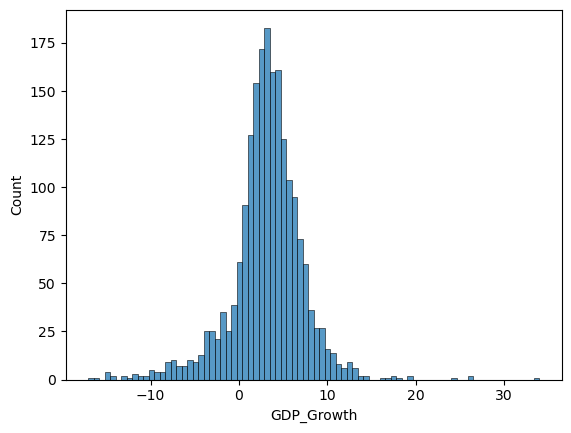

In [40]:
sns.histplot(
    Merged_df['GDP_Growth']
)

plt.show()

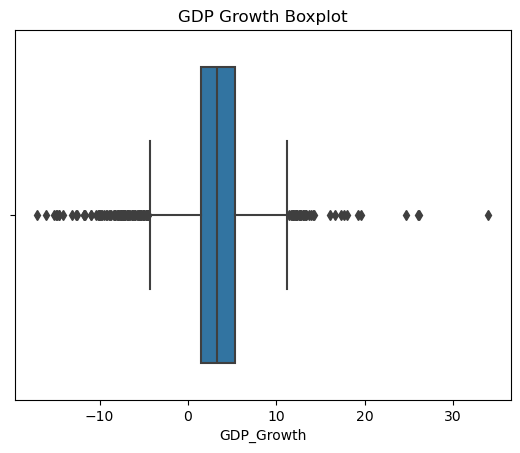

In [41]:
sns.boxplot(
x = Merged_df['GDP_Growth'])
plt.title("GDP Growth Boxplot")
plt.show()

In [42]:
Merged_df.nlargest(
    10,
    'GDP_Growth'
)

,Country_Code,Country,Year,GDP_Growth,Inflation,Unemployment %,Trade %,Population %,CO2 Emission %,School Enrollment %,Foreign_Direct_Investment %
1857,KWT,Kuwait,1993,33.990468,0.382541,0.800,92.057035,2.249187,18.385062,59.364109,0.055352
1093,QAT,Qatar,2006,26.170246,11.835810,0.872,98.570919,16.433257,45.167660,91.352249,5.748812
1780,HND,Honduras,1991,26.046900,33.972260,4.581,89.593512,2.836691,0.479059,32.104881,1.408344
973,IRL,Ireland,2015,24.623986,-0.330960,9.908,223.702938,0.944845,7.887609,116.989868,74.816926
924,QAT,Qatar,2010,19.592174,-2.425257,0.454,87.111197,0.491610,37.673735,98.150179,3.777753
1745,QAT,Qatar,2004,19.218915,6.799337,1.480,90.372429,3.775117,47.941117,90.055252,3.778180
1674,QAT,Qatar,2007,17.985657,13.758163,0.517,96.114106,21.700343,41.392278,91.991570,5.896220
1048,QAT,Qatar,2008,17.663556,15.050145,0.308,89.432842,16.607236,37.338203,97.628860,3.278064
1057,KWT,Kuwait,2003,17.326020,0.961350,5.752,86.555176,2.393819,27.547051,96.062721,-0.140182
1,ZWE,Zimbabwe,2012,16.665429,3.725327,11.069,74.162700,1.623065,0.865176,75.864811,2.043099


In [43]:
Merged_df.nsmallest(
    10,
    'GDP_Growth'
)

,Country_Code,Country,Year,GDP_Growth,Inflation,Unemployment %,Trade %,Population %,CO2 Emission %,School Enrollment %,Foreign_Direct_Investment %
615,VEN,"Venezuela, RB",2016,-17.040335,254.948535,5.319,41.307217,0.625202,4.890726,85.132950,1.405482
288,LVA,Latvia,2009,-16.040020,3.534107,17.515,88.832049,-1.651025,3.438487,99.420403,-0.583936
1024,UKR,Ukraine,2009,-15.136468,15.881192,8.840,87.476163,-0.418318,5.396750,97.377876,3.923419
674,MNE,Montenegro,2020,-14.992619,-0.255656,17.878,87.861203,-0.026010,4.033259,92.357872,11.239441
905,LTU,Lithuania,2009,-14.838612,4.453045,13.785,105.040251,-1.110346,3.696620,104.755882,-0.960671
1075,EST,Estonia,2009,-14.630223,-0.078408,13.548,116.759080,-0.192768,10.526596,107.425552,9.505442
869,MUS,Mauritius,2020,-14.546538,2.580801,8.626,121.125226,0.002291,2.938514,89.502000,1.942469
609,ARM,Armenia,2009,-14.100000,3.406767,19.295,57.274236,-0.685836,1.471233,102.957764,8.788694
1814,IDN,Indonesia,1998,-13.126725,58.451041,5.459,96.186192,1.580718,1.252009,54.271889,-0.252290
1480,BOL,Bolivia,2020,-12.719469,0.940742,7.903,37.516434,1.233964,1.555081,88.867237,-2.669313


In [44]:
corr = Merged_df.corr(numeric_only=True)

print(corr)

                                 Year  GDP_Growth  Inflation  Unemployment %  \
Year                         1.000000   -0.229728  -0.112201       -0.109584   
GDP_Growth                  -0.229728    1.000000  -0.087408       -0.130342   
Inflation                   -0.112201   -0.087408   1.000000       -0.009387   
Unemployment %              -0.109584   -0.130342  -0.009387        1.000000   
Trade %                      0.133156    0.044212  -0.014699       -0.074271   
Population %                -0.119862    0.216375  -0.020036       -0.244014   
CO2 Emission %               0.083449   -0.003280  -0.023454       -0.134666   
School Enrollment %          0.374876   -0.252318  -0.024742        0.040380   
Foreign_Direct_Investment %  0.049232    0.035385  -0.011571       -0.010838   

                              Trade %  Population %  CO2 Emission %  \
Year                         0.133156     -0.119862        0.083449   
GDP_Growth                   0.044212      0.216375      

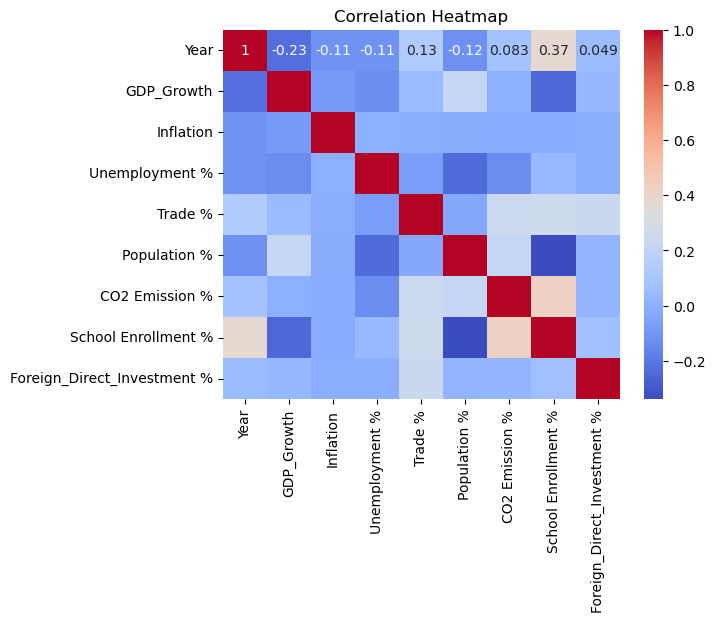

In [45]:
sns.heatmap(corr,
    annot=True,
    cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

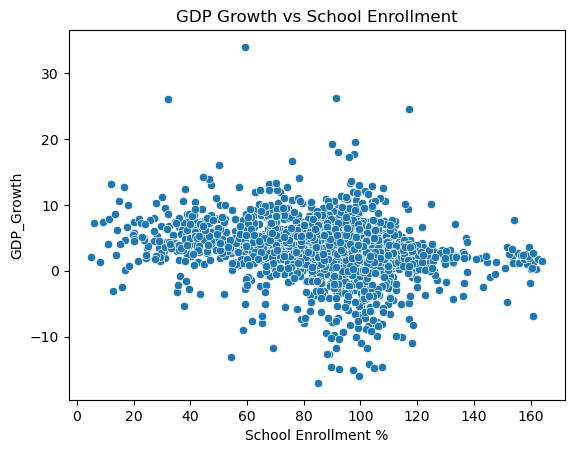

In [46]:
#GDP Growth vs School Enrollment
sns.scatterplot(
    data = Merged_df,
    x = 'School Enrollment %',
    y = 'GDP_Growth'
)
plt.title( "GDP Growth vs School Enrollment")
plt.show()

<Axes: xlabel='Trade %', ylabel='Unemployment %'>

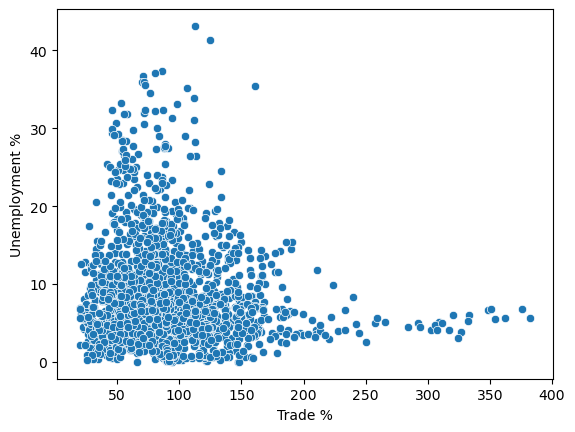

In [48]:
#Trade vs Unemployment
sns.scatterplot(
data = Merged_df,
x = 'Trade %',
y = 'Unemployment %')

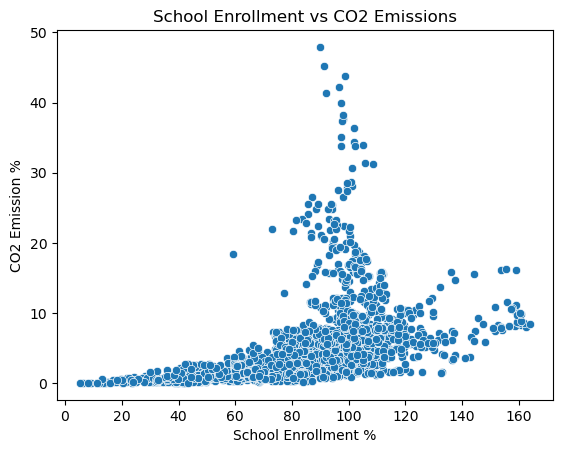

In [49]:
#CO2 Emissions vs School Enrollment
sns.scatterplot(
data = Merged_df,
x = 'School Enrollment %',
y = 'CO2 Emission %')
plt.title("School Enrollment vs CO2 Emissions")
plt.show()

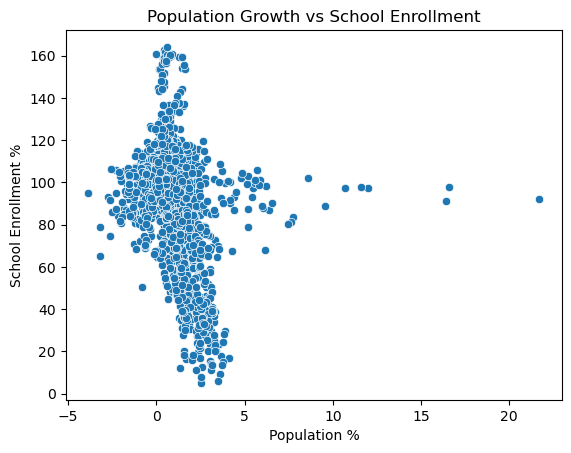

In [50]:
#Population Growth vs School Enrollment
sns.scatterplot(
data=Merged_df,
 x='Population %',
y='School Enrollment %')
plt.title("Population Growth vs School Enrollment")
plt.show()

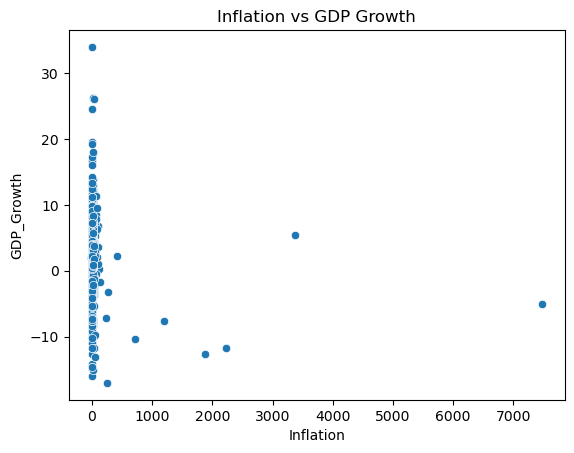

In [51]:
#GDP Growth vs Inflation
sns.scatterplot(
data=Merged_df,
x='Inflation',
y='GDP_Growth')
plt.title( "Inflation vs GDP Growth")
plt.show()

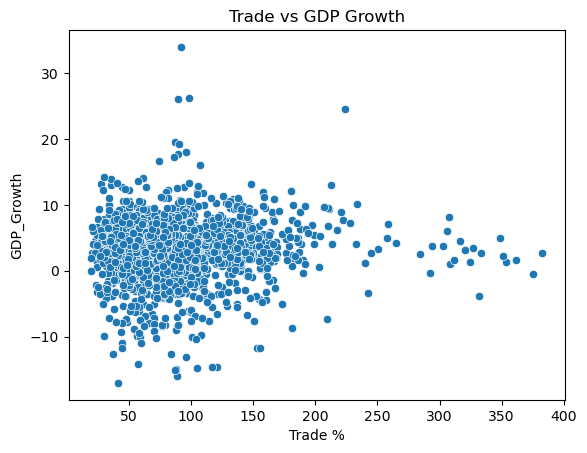

In [53]:
#GDP Growth vs Trade
sns.scatterplot(data=Merged_df,
x='Trade %',
y='GDP_Growth')
plt.title("Trade vs GDP Growth")
plt.show()

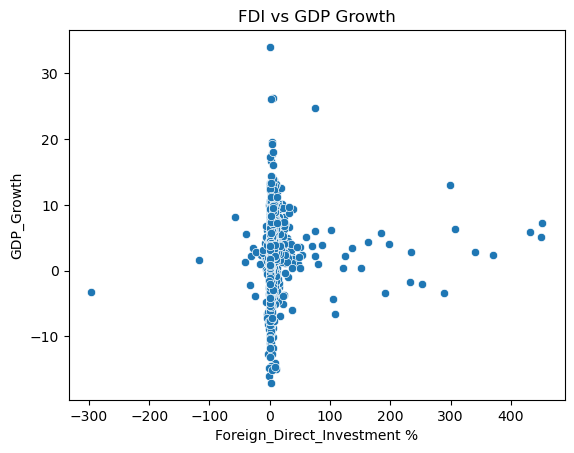

In [54]:
#GDP Growth vs FDI
sns.scatterplot( data=Merged_df,
 x='Foreign_Direct_Investment %',
 y='GDP_Growth')
plt.title("FDI vs GDP Growth")
plt.show()

In [56]:
countries = [
    'United States',
    'Brazil',
    'France',
    'South Africa',
    'India',
    'China',
    'United Arab Emirates',
    'Australia',
    'Japan',
    'United Kingdom'
]

India = Merged_df[Merged_df["Country"] == 'India']

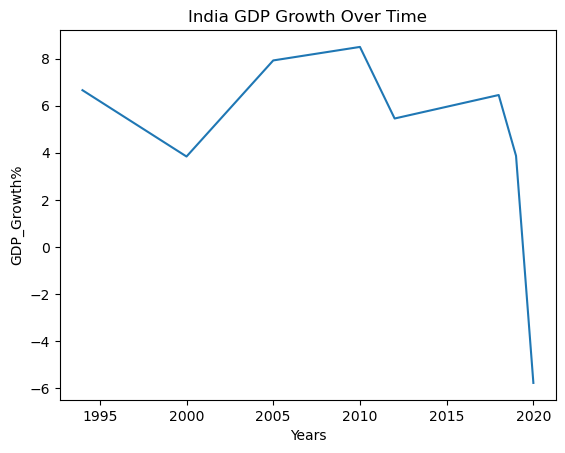

In [66]:
#GDP Growth Trend : INDIA
India = India.sort_values(by = "Year")
plt.plot(India["Year"], India["GDP_Growth"])
plt.title("India GDP Growth Over Time")
plt.xlabel("Years")
plt.ylabel("GDP_Growth%")
plt.show()

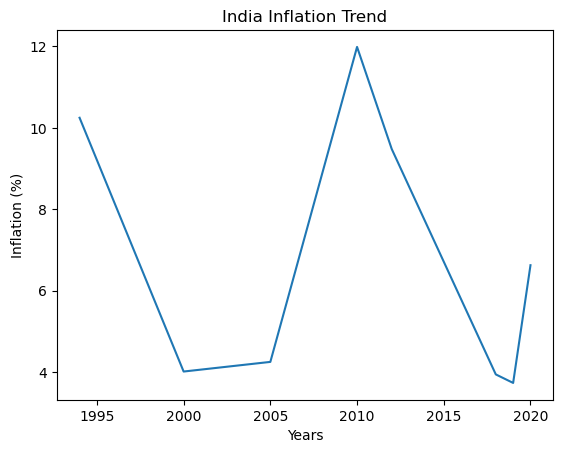

In [67]:
#Inflation Trend : INDIA
plt.plot(India["Year"], India["Inflation"])
plt.title("India Inflation Trend")
plt.xlabel("Years")
plt.ylabel("Inflation (%)")
plt.show()

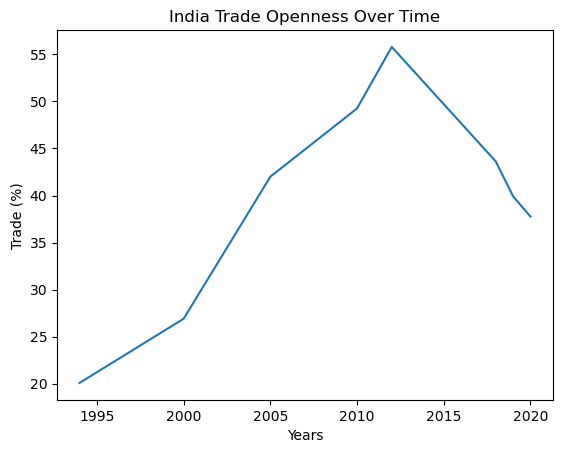

In [68]:
#Trade Trend : INDIA
plt.plot(India["Year"], India["Trade %"])
plt.title("India Trade Openness Over Time")
plt.xlabel("Years")
plt.ylabel("Trade (%)")
plt.show()

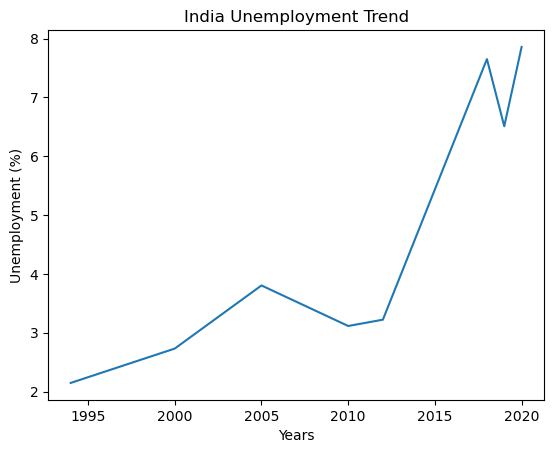

In [69]:
#Unemployment Trend : INDIA
plt.plot(India["Year"], India["Unemployment %"])
plt.title("India Unemployment Trend")
plt.xlabel("Years")
plt.ylabel("Unemployment (%)")
plt.show()

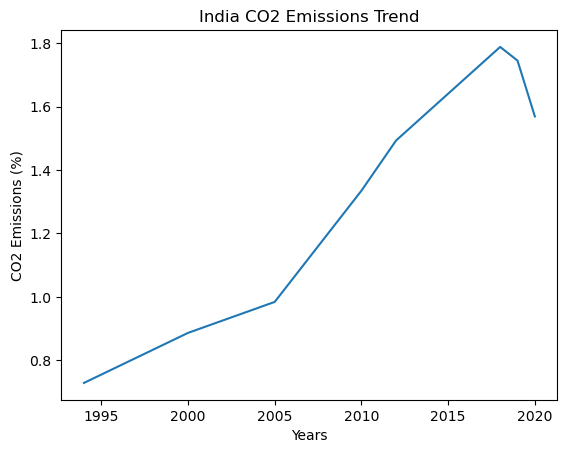

In [70]:
#CO2 Emissions Trend : INDIA
plt.plot(India["Year"], India["CO2 Emission %"])
plt.title("India CO2 Emissions Trend")
plt.xlabel("Years")
plt.ylabel("CO2 Emissions (%)")
plt.show()

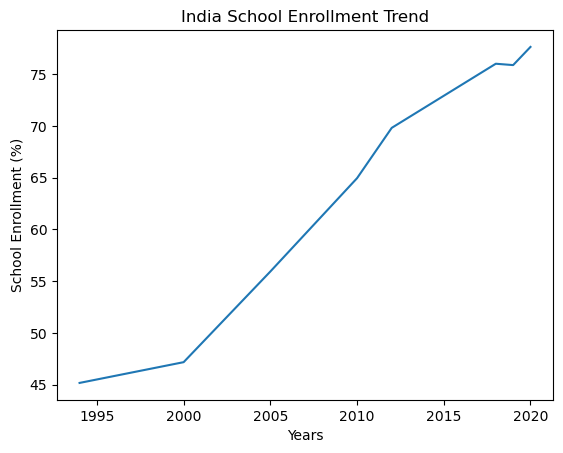

In [71]:
#School Enrollment Trend : INDIA
plt.plot(India["Year"], India["School Enrollment %"])
plt.title("India School Enrollment Trend")
plt.xlabel("Years")
plt.ylabel("School Enrollment (%)")
plt.show()

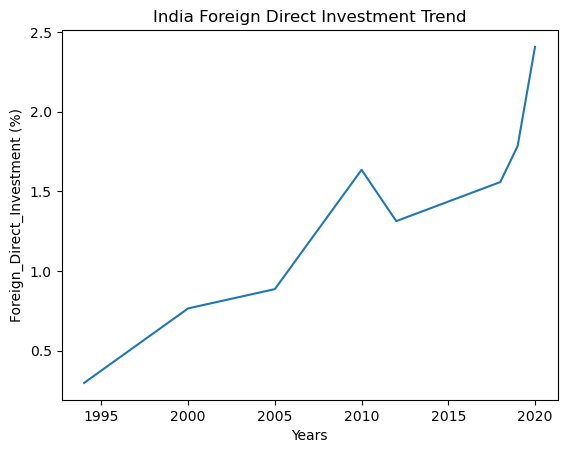

In [72]:
#FDI Trend : INDIA
India = India.sort_values(by = "Year")
plt.plot(India["Year"], India["Foreign_Direct_Investment %"])
plt.title("India Foreign Direct Investment Trend")
plt.xlabel("Years")
plt.ylabel("Foreign_Direct_Investment (%)")
plt.show()


In [73]:
global_df = Merged_df[
    Merged_df['Country'].isin(countries)
]

C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


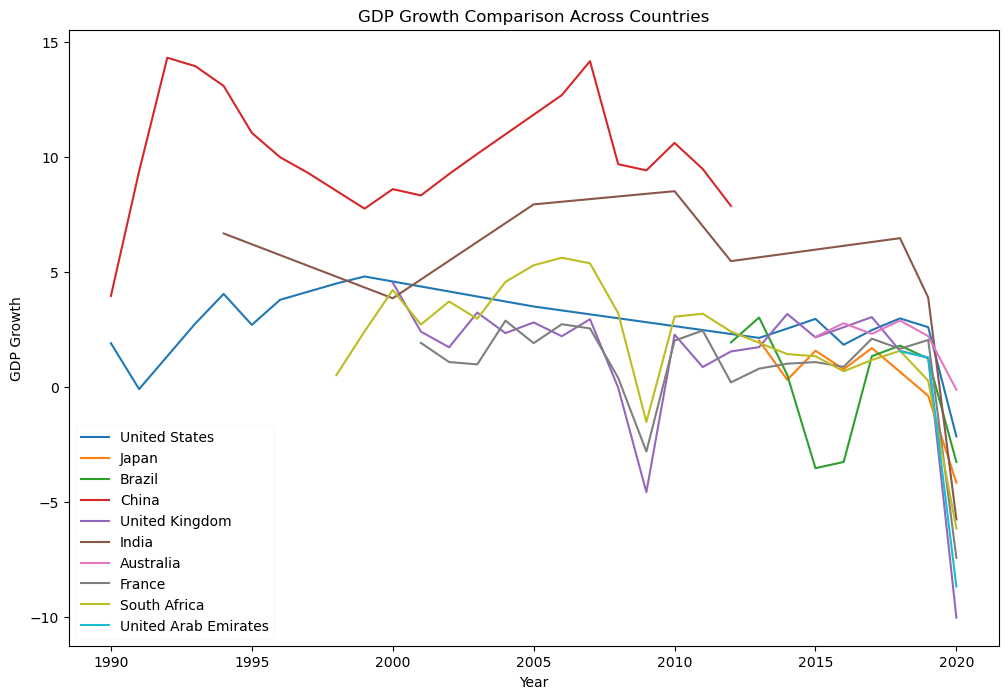

In [74]:
#GDP Growth Comparison
plt.figure(figsize=(12,8))
sns.lineplot(
data=global_df,
 x='Year',
y='GDP_Growth',
hue='Country'
)
plt.legend(framealpha=0.1)
plt.title("GDP Growth Comparison Across Countries")
plt.xlabel("Year")
plt.ylabel("GDP Growth")
plt.show()

C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


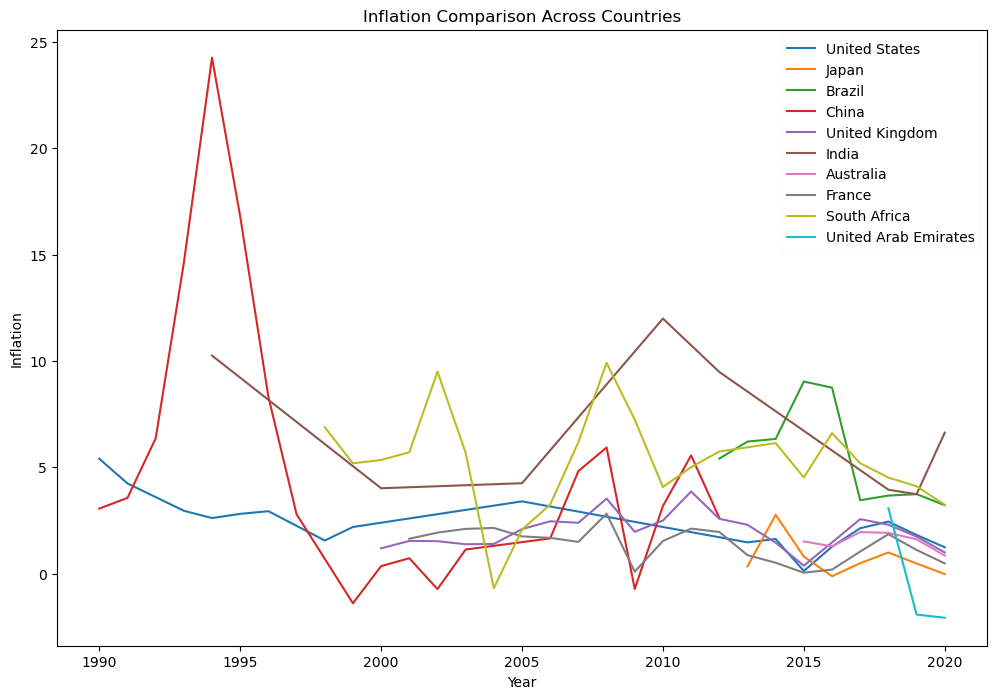

In [75]:
#Inflation Comparison
plt.figure(figsize=(12,8))
sns.lineplot(
data=global_df,
 x='Year',
 y='Inflation',
hue='Country'
)
plt.legend(framealpha=0.1)
plt.title("Inflation Comparison Across Countries")
plt.show()

C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


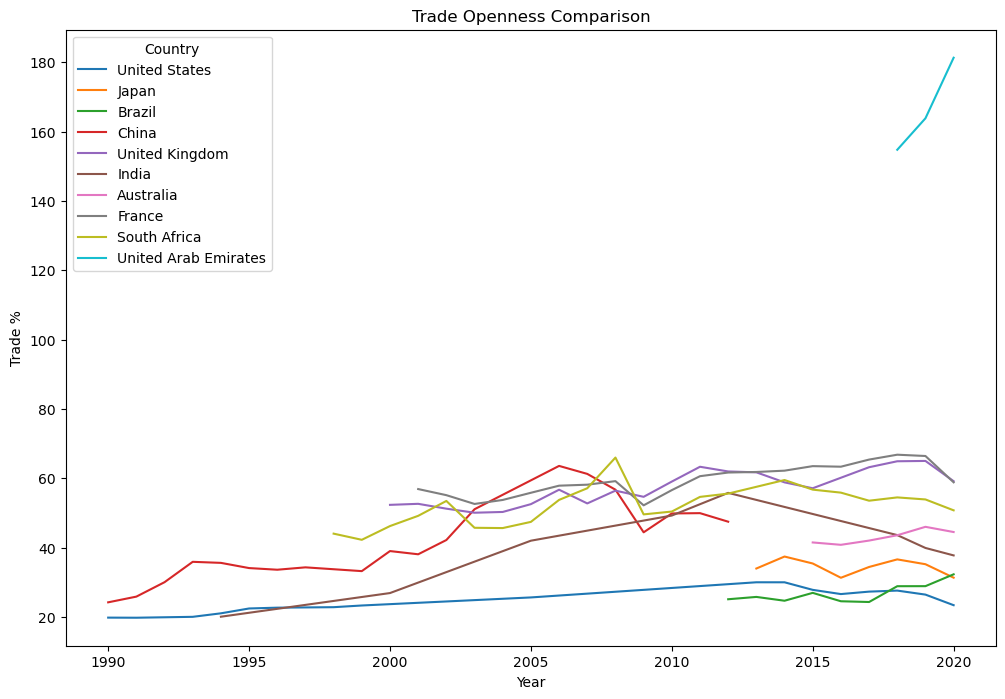

In [77]:
#Trade Comparison
plt.figure(figsize=(12,8))
sns.lineplot(
data=global_df,
x='Year',
y='Trade %',
hue='Country'
)
plt.title("Trade Openness Comparison")
plt.show()

C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


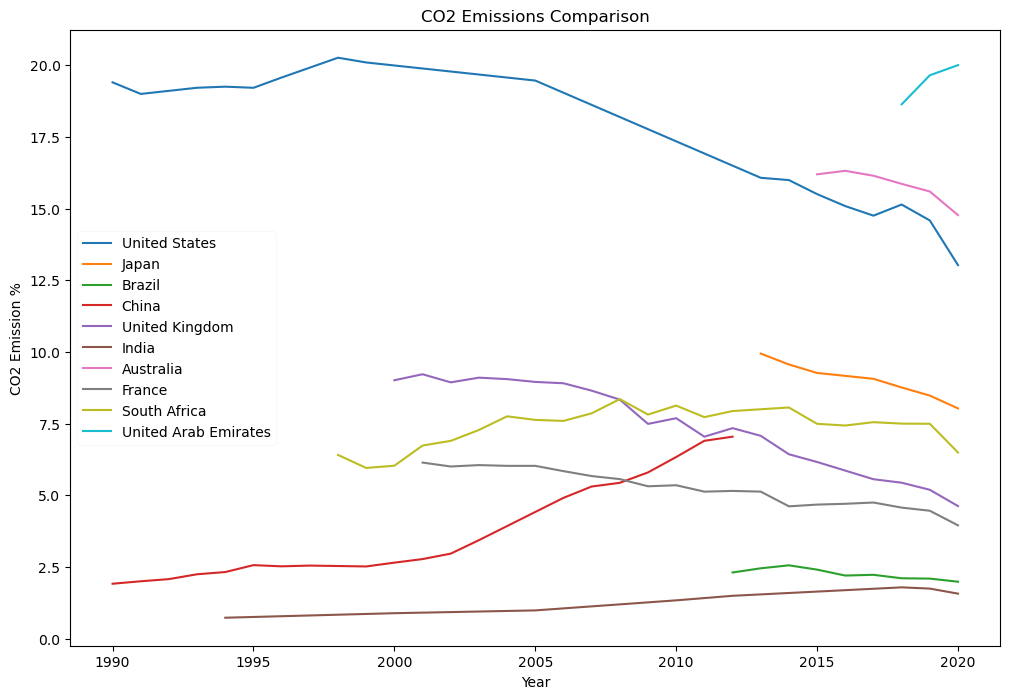

In [78]:
#CO2 Emissions Comparison
plt.figure(figsize=(12,8))
sns.lineplot(
data=global_df,
x='Year',
y='CO2 Emission %',
hue='Country'
)
plt.legend(framealpha=0.1)
plt.title("CO2 Emissions Comparison")
plt.show()

C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


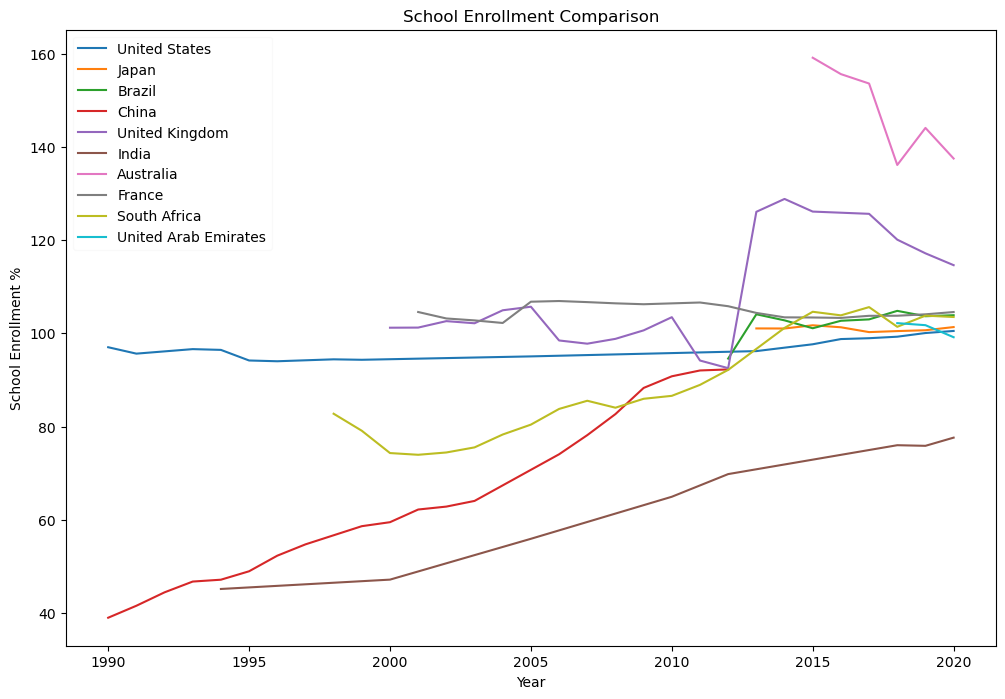

In [79]:
#School Enrollment Comparison
plt.figure(figsize=(12,8))
sns.lineplot(
data=global_df,
x='Year',
y='School Enrollment %',
hue='Country')
plt.legend(framealpha=0.1)
plt.title("School Enrollment Comparison")
plt.show()

C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\krish\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


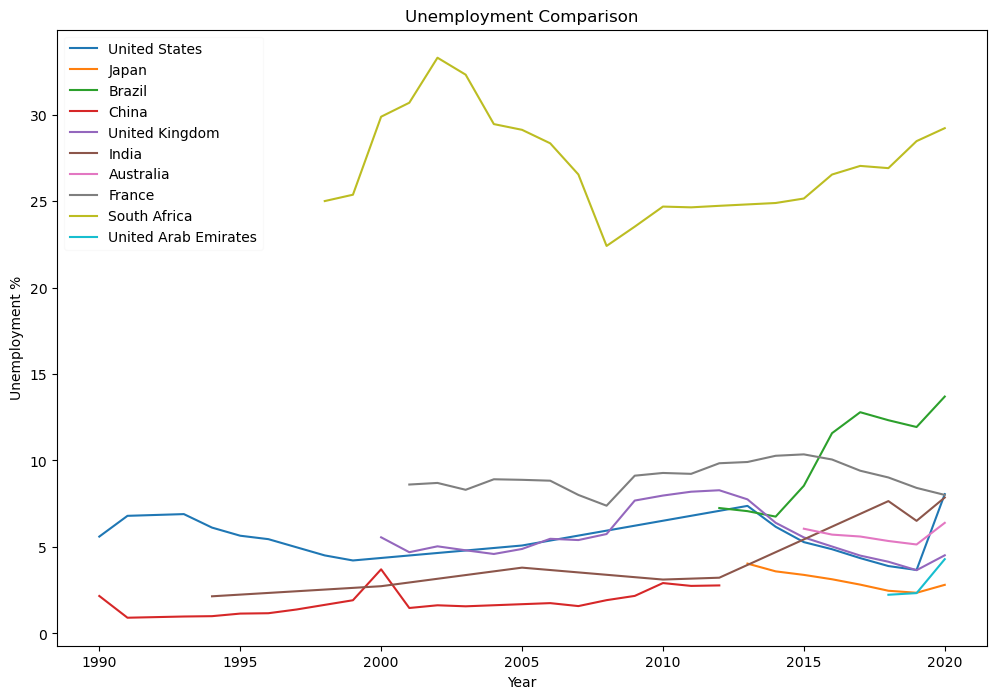

In [80]:
#Unemployment Comparison
plt.figure(figsize=(12,8))
sns.lineplot(
data=global_df,
x='Year',
y='Unemployment %',
hue='Country',
)
plt.legend(framealpha=0.1)
plt.title("Unemployment Comparison")
plt.show()

In [136]:
#Predicting GDP Growth
x = Merged_df[
[
    'Inflation',
    'Unemployment %',
    'Trade %',
    'Population %',
    'CO2 Emission %',
    'School Enrollment %',
    'Foreign_Direct_Investment %',
    'Year'
]
]

y = Merged_df['GDP_Growth']

In [137]:
print(x.head())

   Inflation  Unemployment %    Trade %  Population %  CO2 Emission %  \
0   8.660219          11.464  72.003928      3.113795        0.738803   
1   3.725327          11.069  74.162700      1.623065        0.865176   
2  28.187465           7.112  46.136894      1.309342        5.695381   
3  11.174834          17.821  64.385637      3.138564        0.950569   
4  18.976257          14.971  81.244719      3.212328        0.964330   

   School Enrollment %  Foreign_Direct_Investment %  Year  
0            36.079121                    -4.026534  1999  
1            75.864811                     2.043099  2012  
2            80.724098                     0.402602  2010  
3            39.066231                     0.610358  2010  
4            37.977901                     5.776962  2008  


In [138]:
x

,Inflation,Unemployment %,Trade %,Population %,CO2 Emission %,School Enrollment %,Foreign_Direct_Investment %,Year
0,8.660219,11.464,72.003928,3.113795,0.738803,36.079121,-4.026534,1999
1,3.725327,11.069,74.162700,1.623065,0.865176,75.864811,2.043099,2012
2,28.187465,7.112,46.136894,1.309342,5.695381,80.724098,0.402602,2010
3,11.174834,17.821,64.385637,3.138564,0.950569,39.066231,0.610358,2010
4,18.976257,14.971,81.244719,3.212328,0.964330,37.977901,5.776962,2008
...,...,...,...,...,...,...,...,...
1991,226.005421,26.500,108.785472,-0.606435,0.689644,80.463737,3.066662,1992
1992,31.669662,23.000,49.189084,2.435250,2.510259,60.101250,0.062496,1992
1993,20.642859,17.700,47.130627,-0.629334,0.576804,70.327858,1.730916,1998
1994,8.672486,9.400,71.842452,-1.173982,1.088548,68.452538,12.270780,1998


In [139]:
y

0        3.775530
1       16.665429
2       -1.488791
3        7.701286
4        3.647569
          ...    
1991    -7.187111
1992     1.800002
1993     8.310025
1994     7.300000
1995     0.800001
Name: GDP_Growth, Length: 1996, dtype: float64

In [140]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [141]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [142]:
y_pred = model.predict(x_test)
y_pred

array([1.66436309, 9.15392441, 2.23779243, 3.53262515, 4.46801184,
       3.65525704, 2.58199773, 5.44741197, 2.25345345, 2.58603173,
       2.63544637, 2.72494725, 0.77504768, 2.06666861, 5.37529188,
       2.17429568, 2.76002319, 2.60655278, 4.27797467, 0.58815698,
       1.26543066, 4.02865249, 2.65144859, 1.99374274, 2.38304075,
       4.27731472, 0.49005721, 4.33868918, 4.71906595, 4.07241548,
       4.30960998, 3.47656132, 1.92408028, 2.60457958, 1.65859917,
       2.77474532, 2.12283523, 2.38902799, 3.18672746, 1.77261727,
       2.94105132, 3.75155642, 1.41006178, 2.918104  , 2.84434875,
       6.19346976, 1.10281829, 2.04960557, 2.42844285, 1.41339748,
       4.08656051, 2.68667071, 0.22735195, 1.85497156, 2.84992667,
       2.17518871, 2.51804437, 3.04010266, 2.836511  , 1.61572778,
       1.02585195, 1.02295066, 3.84055694, 5.00057148, 4.69875244,
       1.35022444, 3.01987341, 4.12860456, 2.63581834, 2.35342413,
       1.24402985, 4.06340755, 2.96085487, 3.96986539, 1.70525

In [143]:
mae = mean_absolute_error(y_test, y_pred)
mae

2.8392395452418384

In [144]:
mse = mean_squared_error(y_test, y_pred)
mse

18.420489220798753

In [145]:
r2 = r2_score(y_test, y_pred)
r2

0.13536333038465842

In [146]:
print("Train R²:", model.score(x_train, y_train))
print("Test R²:", model.score(x_test, y_test))

Train R²: 0.13780451062243093
Test R²: 0.13536333038465842


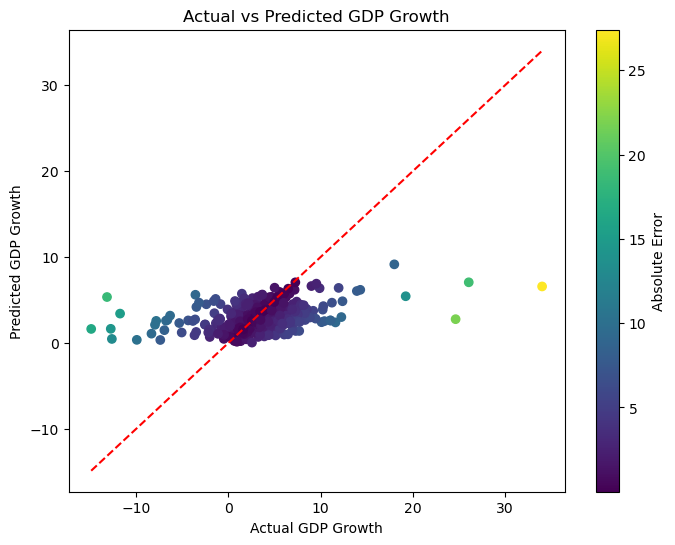

In [152]:
errors = abs(y_test - y_pred)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    c=errors
)

plt.colorbar(label="Absolute Error")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--'
)

plt.xlabel("Actual GDP Growth")
plt.ylabel("Predicted GDP Growth")
plt.title("Actual vs Predicted GDP Growth")

plt.show()